# Lab Activity Sheet, Student Copy
## Quantum Circuits using Qiskit

## Pre-Lab Setup

In [10]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Activity 1: Building & Visualizing Circuits (25 minutes)

### Task 1.1 - Your first circuit

In [11]:
qr = QuantumRegister(1, 'q')
cr = ClassicalRegister(1, 'c')
qc1 = QuantumCircuit(qr, cr)
qc1.x(0)
qc1.h(0)              # apply the Hadamard gate after X

print(qc1.draw(output='text'))
print('depth:', qc1.depth(), 'size:', qc1.size(), 'width:', qc1.width())

     ┌───┐┌───┐
  q: ┤ X ├┤ H ├
     └───┘└───┘
c: 1/══════════
               
depth: 2 size: 2 width: 2


### Task 1.2 - Building a circuit from a list of gates

In [12]:
qc2 = QuantumCircuit(1)
gate_sequence = ['h', 'x', 'h', 'z']
for g in gate_sequence:
    getattr(qc2, g)(0)      # apply the gate named by the loop variable 'g'

print(qc2.draw(output='text'))

   ┌───┐┌───┐┌───┐┌───┐
q: ┤ H ├┤ X ├┤ H ├┤ Z ├
   └───┘└───┘└───┘└───┘


Figure(436.286x117.056)


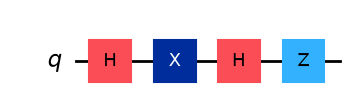

In [13]:
qc2 = QuantumCircuit(1)
gate_sequence = ['h', 'x', 'h', 'z']
for g in gate_sequence:
    getattr(qc2, g)(0)      # apply the gate named by the loop variable 'g'

print(qc2.draw(output='mpl'))

### Task 1.3 - Using a barrier

In [19]:
qc3 = QuantumCircuit(1)
qc3.h(0)
qc3.barrier()  
qc3.x(0)

print(qc3.draw(output='text'))

   ┌───┐ ░ ┌───┐
q: ┤ H ├─░─┤ X ├
   └───┘ ░ └───┘


## Activity 2: Composing Single-Qubit Gate Circuits (30 minutes)

### Task 2.1 - Composing two circuits

In [21]:
circA = QuantumCircuit(1)
circA.h(0)
circB = QuantumCircuit(1)
circB.x(0)

composed = circA.compose(circB)     # compose circA with circB
print(composed.draw(output='text'))

direct = QuantumCircuit(1)
direct.h(0); direct.x(0)
print('Same unitary?', np.allclose(Operator(composed).data, Operator(direct).data))

   ┌───┐┌───┐
q: ┤ H ├┤ X ├
   └───┘└───┘
Same unitary? True


### Task 2.2 - Verifying gate identities at the circuit level

In [22]:
qc_hh = QuantumCircuit(1); qc_hh.h(0); qc_hh.h(0)
print('H*H matrix ='); print(Operator(qc_hh).data.round(3))

qc_ss = QuantumCircuit(1); qc_ss.s(0); qc_ss.s(0)
print('S*S matrix ='); print(Operator(qc_ss).data.round(3))

qc_tt = QuantumCircuit(1); qc_tt.t(0); qc_tt.t(0)
print('T*T matrix ='); print(Operator(qc_tt).data.round(3))

qc_hxh = QuantumCircuit(1)
qc_hxh.h(0); qc_hxh.x(0); qc_hxh.h(0)   # apply the final H
print('H*X*H matrix ='); print(Operator(qc_hxh).data.round(3))

H*H matrix =
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
S*S matrix =
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]
T*T matrix =
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+1.j]]
H*X*H matrix =
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]


### Task 2.3 - Building a circuit's inverse

In [25]:
qc = QuantumCircuit(1)
qc.h(0); qc.s(0); qc.x(0)
print(qc.draw(output='text'))

qc_inv = qc.inverse()      
print(qc_inv.draw(output='text'))

full = qc.compose(qc_inv)
print('Statevector after circuit + inverse:', Statevector.from_instruction(full))

   ┌───┐┌───┐┌───┐
q: ┤ H ├┤ S ├┤ X ├
   └───┘└───┘└───┘
   ┌───┐┌─────┐┌───┐
q: ┤ X ├┤ Sdg ├┤ H ├
   └───┘└─────┘└───┘
Statevector after circuit + inverse: Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


## Activity 3: The CNOT Gate, Two-Qubit Circuits (35 minutes)

### Task 3.1 - A 2-qubit circuit with CNOT

In [28]:
qr = QuantumRegister(2, 'q')
cr = ClassicalRegister(2, 'c')
base = QuantumCircuit(qr, cr)
base.cx(0, 1)          
print(base.draw(output='text'))

for q0_val, q1_val in [(0, 0), (0, 1), (1, 0), (1, 1)]:
    qc = QuantumCircuit(2)
    if q0_val: qc.x(0)
    if q1_val: qc.x(1)
    qc.cx(0, 1)
    sv = Statevector.from_instruction(qc)
    print(f'Input |{q0_val}{q1_val}> -> {sv}')

          
q_0: ──■──
     ┌─┴─┐
q_1: ┤ X ├
     └───┘
c: 2/═════
          
Input |00> -> Statevector([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))
Input |01> -> Statevector([0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
            dims=(2, 2))
Input |10> -> Statevector([0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
            dims=(2, 2))
Input |11> -> Statevector([0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))


### Task 3.2 - Building the Bell-state circuit

In [30]:
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)      
print(bell.draw(output='text'))
print(Statevector.from_instruction(bell))

     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


### Task 3.3 - Adding a barrier and measurement

In [31]:
bell_m = QuantumCircuit(2, 2)
bell_m.h(0)
bell_m.cx(0, 1)
bell_m.barrier()
bell_m.measure([0, 1], [0, 1])     # this line is already complete, just run it
print(bell_m.draw(output='text'))

     ┌───┐      ░ ┌─┐   
q_0: ┤ H ├──■───░─┤M├───
     └───┘┌─┴─┐ ░ └╥┘┌─┐
q_1: ─────┤ X ├─░──╫─┤M├
          └───┘ ░  ║ └╥┘
c: 2/══════════════╩══╩═
                   0  1 


### Task 3.4 - Challenge: The other three Bell states

In [33]:
variants = {
    'Phi+': [],
    'Phi-': [('z', 0)],
    'Psi+': [('x', 1)],
    'Psi-': [('z', 0), ('x', 1)],         
}

for name, extra_gates in variants.items():
    qc = QuantumCircuit(2)
    qc.h(0)
    qc.cx(0, 1)
    for gate, qubit in extra_gates:
        getattr(qc, gate)(qubit)
    sv = Statevector.from_instruction(qc)
    print(f'{name}: {sv}')

Phi+: Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))
Phi-: Statevector([ 0.70710678+0.j,  0.        +0.j,  0.        +0.j,
             -0.70710678+0.j],
            dims=(2, 2))
Psi+: Statevector([0.        +0.j, 0.70710678+0.j, 0.70710678+0.j,
             0.        +0.j],
            dims=(2, 2))
Psi-: Statevector([ 0.        +0.j, -0.70710678+0.j,  0.70710678+0.j,
              0.        +0.j],
            dims=(2, 2))


## Activity 4: Measurement in Circuits (20 minutes)

### Task 4.1 - Manually adding measurement

In [36]:
qc = QuantumCircuit(1, 1)
qc.h(0)
qc.measure(0, 0)       
print(qc.draw(output='text'))

sim = AerSimulator()
compiled = transpile(qc, sim)
result = sim.run(compiled, shots=1024).result()
print(result.get_counts())

     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 
{'1': 506, '0': 518}


### Task 4.2 - Using measure_all()

In [37]:
qc2 = QuantumCircuit(1)
qc2.h(0)
qc2_m = qc2.measure_all(inplace=False)     
print(qc2_m.draw(output='text'))

compiled2 = transpile(qc2_m, sim)
result2 = sim.run(compiled2, shots=1024).result()
print(result2.get_counts())

        ┌───┐ ░ ┌─┐
     q: ┤ H ├─░─┤M├
        └───┘ ░ └╥┘
meas: 1/═════════╩═
                 0 
{'1': 502, '0': 522}


### Task 4.3 - Measuring the Bell-state circuit

In [38]:
compiled3 = transpile(bell_m, sim)
for shots in [100, 1024, 8192]:
    result3 = sim.run(compiled3, shots=shots).result()
    print(f'shots={shots}:', result3.get_counts())

shots=100: {'00': 53, '11': 47}
shots=1024: {'11': 502, '00': 522}
shots=8192: {'00': 4068, '11': 4124}
